In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os, random, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report

print("TensorFlow version:", tf.__version__)

BASE_DIR  = "/content/drive/MyDrive/AI/FruitinAmazon"   # folder containing train/ and test/
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_HEIGHT  = 128
IMG_WIDTH   = 128
BATCH_SIZE  = 16
EPOCHS      = 250
VAL_SPLIT   = 0.2
SEED        = 42

TensorFlow version: 2.19.0


## Task 1 — Data Understanding & Visualization
### 1a. Visualise one image per class

Classes (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
  acai        : 15 images
  cupuacu     : 15 images
  graviola    : 15 images
  guarana     : 15 images
  pupunha     : 15 images
  tucuma      : 15 images


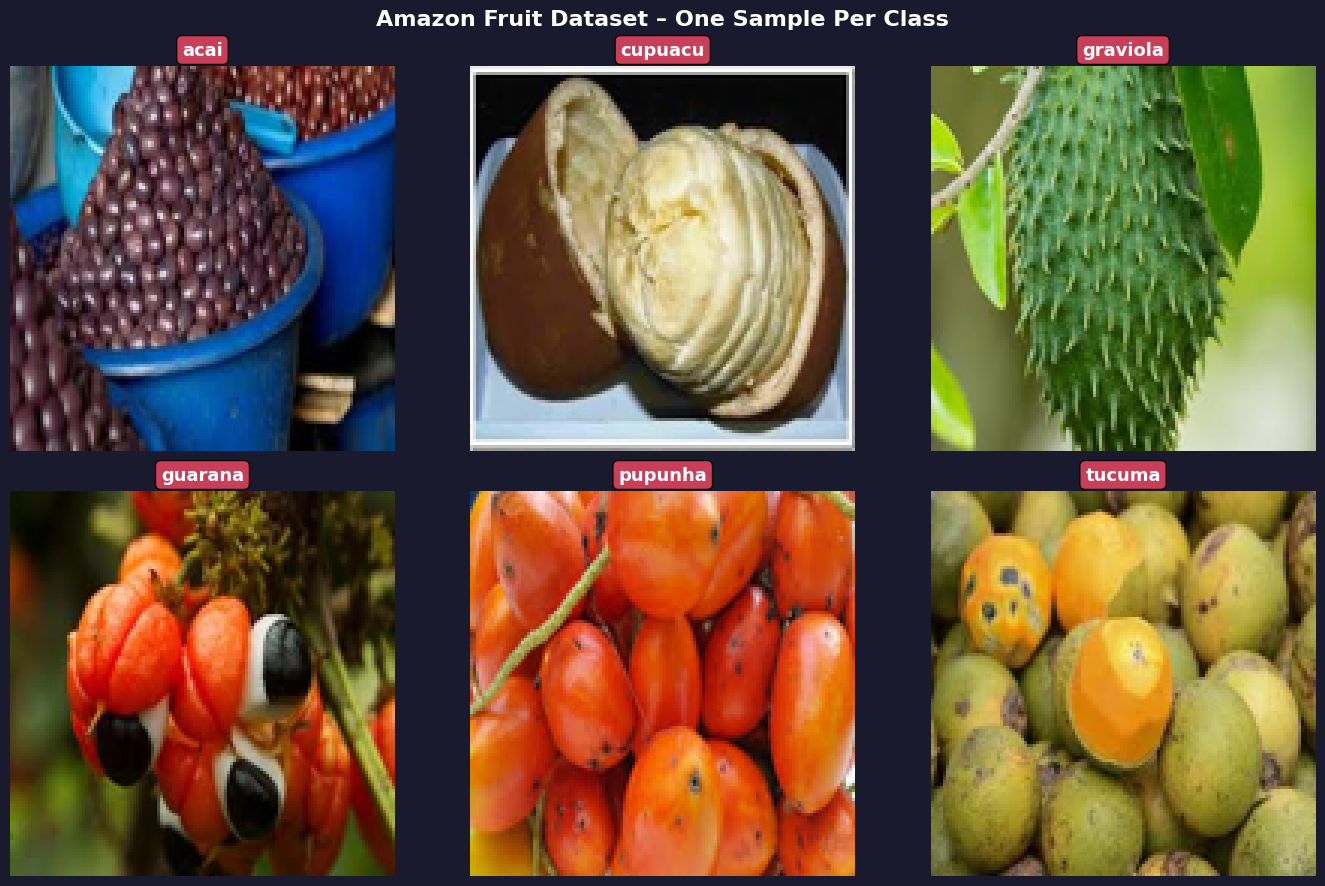

In [6]:
classes = sorted(os.listdir(TRAIN_DIR))
print(f"Classes ({len(classes)}): {classes}")
for c in classes:
    print(f"  {c:12s}: {len(os.listdir(os.path.join(TRAIN_DIR, c)))} images")

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.patch.set_facecolor('#1a1a2e')
axes = axes.flatten()

for idx, cls in enumerate(classes):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    img_file = random.choice(os.listdir(cls_dir))
    img = Image.open(os.path.join(cls_dir, img_file)).convert("RGB").resize((IMG_WIDTH, IMG_HEIGHT))
    ax = axes[idx]
    ax.imshow(img)
    ax.set_title(cls, fontsize=13, fontweight='bold', color='white', pad=8,
                 bbox=dict(boxstyle='round,pad=0.3', fc='#e94560', alpha=0.85))
    ax.axis('off')

for ax in axes[len(classes):]:
    ax.set_visible(False)

plt.suptitle("Amazon Fruit Dataset – One Sample Per Class",
             fontsize=16, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

**Observation:** The dataset contains 5 Amazon fruit classes. Each class has very few images (2–12),
making the dataset small and imbalanced. Images vary in resolution, background, and lighting,
which will challenge the model's ability to generalise.

### 1b. Check for Corrupted Images

In [7]:
corrupted = []
for cls in classes:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_dir):
        fpath = os.path.join(cls_dir, fname)
        try:
            img = Image.open(fpath)
            img.verify()
        except (IOError, SyntaxError):
            corrupted.append(fpath)
            os.remove(fpath)
            print(f"Removed corrupted image: {fpath}")

if not corrupted:
    print("No Corrupted Images Found.")
else:
    print(f"Total removed: {len(corrupted)} corrupted image(s).")

No Corrupted Images Found.


## Task 2 — Loading & Preprocessing Data

In [8]:
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR, labels='inferred', label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH), interpolation='nearest',
    batch_size=BATCH_SIZE, shuffle=True,
    validation_split=VAL_SPLIT, subset='training', seed=SEED
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR, labels='inferred', label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH), interpolation='nearest',
    batch_size=BATCH_SIZE, shuffle=False,
    validation_split=VAL_SPLIT, subset='validation', seed=SEED
)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f"Class names : {CLASS_NAMES}")
print(f"Num classes : {NUM_CLASSES}")

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds   = val_ds.map(lambda x, y: (rescale(x), y))

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR, labels='inferred', label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH), interpolation='nearest',
    batch_size=BATCH_SIZE, shuffle=False, seed=SEED
)
test_class_names = test_ds.class_names
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Class names : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes : 6
Found 30 files belonging to 6 classes.


## Task 3 — Build the CNN

In [9]:
model = keras.Sequential([
    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    # Convolutional Block 2
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    # Fully Connected Network
    layers.Flatten(),
    layers.Dense(64,  activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name="FruitCNN")

model.summary()

Model: "FruitCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4 — Compile & Train

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='best_model.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, verbose=1
    )
]

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.1062 - loss: 1.9380
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 371ms/step - accuracy: 0.1250 - loss: 1.9238 - val_accuracy: 0.0000e+00 - val_loss: 2.1094 - learning_rate: 0.0010
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.3212 - loss: 1.6806
Epoch 2: val_accuracy did not improve from 0.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 326ms/step - accuracy: 0.3611 - loss: 1.6292 - val_accuracy: 0.0000e+00 - val_loss: 1.9260 - learning_rate: 0.0010
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.3656 - loss: 1.4849
Epoch 3: val_accuracy improved from 0.00000 to 0.22222, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 545ms/step - accuracy: 0.4167 - loss: 1.3862 - val_accuracy: 0.2222 - val_loss: 1.8381 - learning_rat

## Task 5 — Evaluate the Model

Test Loss     : 1.1240
Test Accuracy : 0.6000  (60.0%)


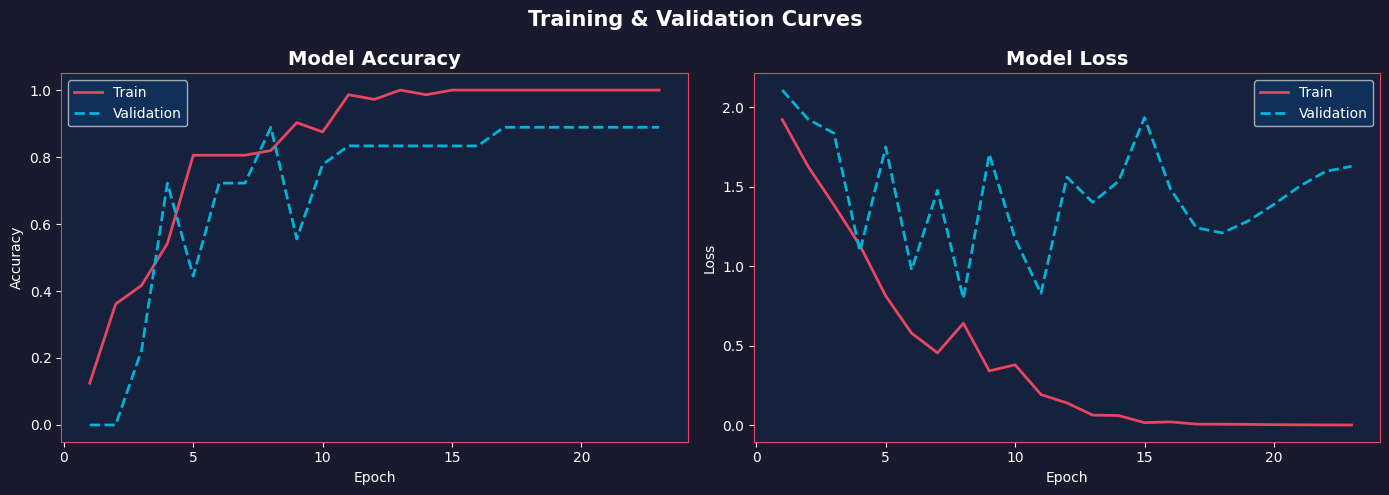

In [11]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1a1a2e')
for ax in axes:
    ax.set_facecolor('#16213e')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values(): spine.set_edgecolor('#e94560')

ep = range(1, len(history.history['accuracy']) + 1)
axes[0].plot(ep, history.history['accuracy'],     color='#e94560', lw=2, label='Train')
axes[0].plot(ep, history.history['val_accuracy'], color='#00b4d8', lw=2, ls='--', label='Validation')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(facecolor='#0f3460', labelcolor='white')

axes[1].plot(ep, history.history['loss'],     color='#e94560', lw=2, label='Train')
axes[1].plot(ep, history.history['val_loss'], color='#00b4d8', lw=2, ls='--', label='Validation')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(facecolor='#0f3460', labelcolor='white')

plt.suptitle('Training & Validation Curves', fontsize=15, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

## Task 6 — Save & Load the Model

In [12]:
model.save("fruit_cnn_model.h5")
print("Model saved → fruit_cnn_model.h5")

loaded_model = keras.models.load_model("fruit_cnn_model.h5")
r_loss, r_acc = loaded_model.evaluate(test_ds, verbose=0)
print(f"Reloaded model — Test Accuracy: {r_acc:.4f}")

Model saved → fruit_cnn_model.h5
Reloaded model — Test Accuracy: 0.6000


## Task 7 — Predictions & Classification Report

In [13]:
y_true, y_pred = [], []
for imgs, labels in test_ds:
    preds = loaded_model.predict(imgs, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=test_class_names, zero_division=0))

              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       0.50      0.80      0.62         5
    graviola       1.00      1.00      1.00         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.57      0.80      0.67         5
      tucuma       0.33      0.40      0.36         5

    accuracy                           0.60        30
   macro avg       0.53      0.60      0.55        30
weighted avg       0.53      0.60      0.55        30

